# 16-liver-clonotype-networks

In [1]:
import scanpy as sc
import scirpy as ir
import numpy as np
import json
from pathlib import Path
import pandas as pd
import muon as mu
import anndata as ad
import re
import warnings
warnings.filterwarnings('ignore')

DATA = Path("data")

/Users/alegator1209/micromamba/envs/pytcr/lib/python3.12/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 2.2.0 when it was built against 2.1.0, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


Matplotlib is building the font cache; this may take a moment.


/Users/alegator1209/micromamba/envs/pytcr/lib/python3.12/site-packages/muon/_core/preproc.py:32: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
def read_vdj(path: Path):
  adata = ir.io.read_10x_vdj(path)
  ir.pp.index_chains(adata)
  ir.tl.chain_qc(adata)
  return adata

def read_sample(path: Path) -> tuple[ad.AnnData, ad.AnnData, ad.AnnData]:
  mtx = next(path.glob("*_GEX_matrix.mtx.gz"))
  prefix = mtx.name[: -len("matrix.mtx.gz")]

  adata_gex = sc.read_10x_mtx(path, var_names="gene_symbols", prefix=prefix)
  adata_gex.var_names_make_unique()
  sc.pp.filter_cells(adata_gex, min_genes=200)
  sc.pp.filter_genes(adata_gex, min_cells=3)
  adata_gex.var["mt"] = adata_gex.var_names.str.startswith("MT-")
  sc.pp.calculate_qc_metrics(adata_gex, qc_vars=["mt"], inplace=True, log1p=True)
  mu.pp.filter_obs(adata_gex, 'pct_counts_mt', lambda x: x < 10)

  adata_tcr = read_vdj(next(path.glob("*_TCR_filtered_contig_annotations.csv.gz")))
  mu.pp.filter_obs(adata_tcr, "receptor_subtype", lambda x: ~np.isin(x, ["multichain", "ambiguous", "no IR"]))
  mu.pp.filter_obs(adata_tcr, "chain_pairing", lambda x: x == "single pair")

  adata_bcr = read_vdj(next(path.glob("*_BCR_filtered_contig_annotations.csv.gz")))
  mu.pp.filter_obs(adata_bcr, "receptor_subtype", lambda x: ~np.isin(x, ["multichain", "ambiguous", "no IR"]))
  mu.pp.filter_obs(adata_bcr, "chain_pairing", lambda x: x == "single pair")

  return adata_gex, adata_tcr, adata_bcr

In [3]:
SAMPLE_RE = re.compile(r"Patient(\d+)-(.+)")

adatas_gex = {}
adatas_tcr = {}
adatas_bcr = {}

for sample_dir in sorted(DATA.glob("*/*")):
  if not sample_dir.is_dir():
    continue

  match = SAMPLE_RE.fullmatch(sample_dir.name)
  if not match:
    continue

  sample = sample_dir.name
  patient, condition = match.group(1), match.group(2)
  status = sample_dir.parent.name

  gex, tcr, bcr = read_sample(sample_dir)

  for adata in (gex, tcr, bcr):
    adata.obs["sample"] = sample
    adata.obs["patient"] = patient
    adata.obs["condition"] = condition
    adata.obs["status"] = status
    adata.obs["pre_transplant"] = status == "Pre-TXP"

  adatas_gex[sample] = gex
  adatas_tcr[sample] = tcr
  adatas_bcr[sample] = bcr

adata_gex = ad.concat(adatas_gex, index_unique="_")
adata_tcr = ad.concat(adatas_tcr, index_unique="_")
adata_bcr = ad.concat(adatas_bcr, index_unique="_")

mdata = mu.MuData({
  "gex": adata_gex,
  "tcr": adata_tcr,
  "bcr": adata_bcr,
})

mdata

MuData object with n_obs × n_vars = 10521 × 4829
  3 modalities
    gex:	7194 × 4829
      obs:	'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'sample', 'patient', 'condition', 'status', 'pre_transplant'
      layers:	None
    tcr:	2332 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient', 'condition', 'status', 'pre_transplant'
      obsm:	'airr', 'chain_indices'
    bcr:	3122 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient', 'condition', 'status', 'pre_transplant'
      obsm:	'airr', 'chain_indices'

In [4]:
ir.pp.ir_dist(mdata, airr_mod="tcr")
ir.tl.define_clonotypes(mdata, airr_mod="tcr", receptor_arms="all", dual_ir="primary_only")
ir.tl.clonal_expansion(mdata, airr_mod="tcr")
mdata

MuData object with n_obs × n_vars = 10521 × 4829
  3 modalities
    gex:	7194 × 4829
      obs:	'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'sample', 'patient', 'condition', 'status', 'pre_transplant'
      layers:	None
    tcr:	2332 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient', 'condition', 'status', 'pre_transplant', 'clone_id', 'clone_id_size', 'clonal_expansion'
      uns:	'ir_dist_nt_identity', 'clone_id'
      obsm:	'airr', 'chain_indices'
    bcr:	3122 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient', 'condition', 'status', 'pre_transplant'
      obsm:	'airr', 'chain_indices'

In [5]:
ir.pp.ir_dist(
  mdata,
  airr_mod="tcr",
  metric="tcrdist",
  sequence="aa",
  cutoff=15,
)

ir.tl.define_clonotype_clusters(mdata, airr_mod="tcr", sequence="aa", metric="tcrdist", receptor_arms="all", dual_ir="any")

ir.tl.clonotype_network(mdata, airr_mod="tcr", min_cells=3, sequence="aa", metric="tcrdist")

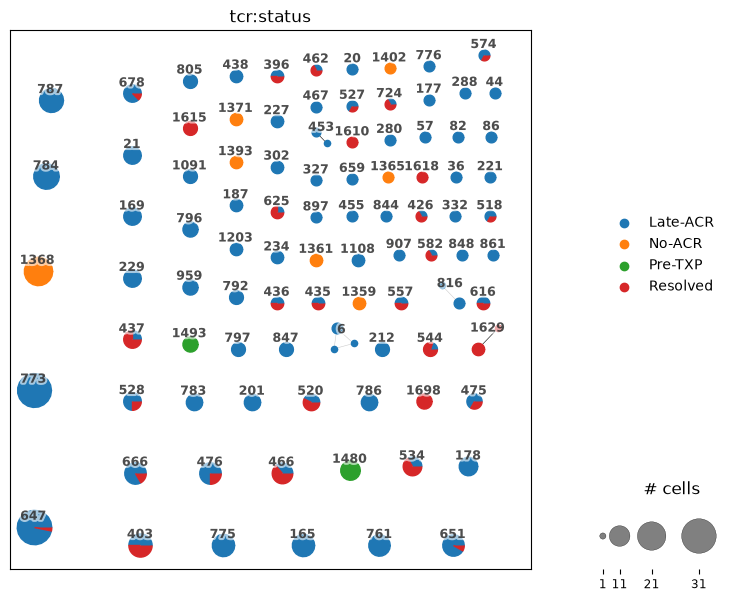

In [6]:
_ = ir.pl.clonotype_network(mdata, airr_mod="tcr", color="tcr:status", base_size=20, label_fontsize=9, panel_size=(7, 7))

In [7]:
ir.tl.clonal_expansion(mdata, airr_mod="tcr")
mdata

MuData object with n_obs × n_vars = 10521 × 4829
  3 modalities
    gex:	7194 × 4829
      obs:	'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'sample', 'patient', 'condition', 'status', 'pre_transplant'
      layers:	None
    tcr:	2332 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient', 'condition', 'status', 'pre_transplant', 'clone_id', 'clone_id_size', 'clonal_expansion', 'cc_aa_tcrdist', 'cc_aa_tcrdist_size'
      uns:	'ir_dist_nt_identity', 'clone_id', 'ir_dist_aa_tcrdist', 'cc_aa_tcrdist', 'clonotype_network'
      obsm:	'airr', 'chain_indices', 'X_clonotype_network'
    bcr:	3122 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient', 'condition', 'status', 'pre_transplant'
      obsm:	'airr', 'chain_indices'

In [8]:
def biopsy_order(condition: str) -> int:
  return -1 if condition == "Pre-TXP" else int(condition.removeprefix("BX"))

obs = mdata["tcr"].obs.copy()
obs["order"] = obs["condition"].map(biopsy_order)

In [9]:
p11 = obs[obs["patient"] == "11"].sort_values("order")
p11["is_expanded"] = p11["clonal_expansion"] == "> 2"
first_sample = p11.iloc[0]["sample"]
last_sample = p11.iloc[-1]["sample"]

expanded_first = set(p11[(p11["sample"] == first_sample) & p11["is_expanded"]]["clone_id"])
present_last = set(p11[p11["sample"] == last_sample]["clone_id"])
shared = expanded_first & present_last

patient_11_clonal_expansion_proportion = len(shared) / len(expanded_first)
print(f"Proportion of patient 11 first biopsy expanded clonotypes present in last biopsy: {patient_11_clonal_expansion_proportion}")

Proportion of patient 11 first biopsy expanded clonotypes present in last biopsy: 0.75


In [13]:
p12 = obs[obs["patient"] == "12"].sort_values("order")
p12.groupby(["condition", "status"]).count()
p12["is_expanded"] = p12["clonal_expansion"] == "> 2"

p12[p12["condition"] == "BX1"]["is_expanded"].mean()

per_biopsy = p12.groupby(["patient", "order", "condition", "status"], observed=True).agg(
  n_cells=("clone_id", "size"),
  n_clonotypes=("clone_id", "nunique"),
  expansion=("is_expanded", "mean"),
).round(3).reset_index()

between_statuses = abs(per_biopsy.iloc[2]["expansion"] - per_biopsy.iloc[1]["expansion"])

inside_statuses = max(
  abs(per_biopsy.iloc[1]["expansion"] - per_biopsy.iloc[0]["expansion"]),
  abs(per_biopsy.iloc[3]["expansion"] - per_biopsy.iloc[2]["expansion"]),
  abs(per_biopsy.iloc[4]["expansion"] - per_biopsy.iloc[3]["expansion"]),
)

patient_12_expansion_change = "inside" if inside_statuses > between_statuses else "between"
patient_12_expansion_delta = inside_statuses if inside_statuses > between_statuses else between_statuses

print(f"Change inside statuses: {inside_statuses}")
print(f"Change between statuses: {between_statuses}")

Change inside statuses: 0.098
Change between statuses: 0.08500000000000002


In [14]:
networks = obs.groupby("cc_aa_tcrdist", observed=True).agg(
  n_cells=("status", "size"),
  n_clonotypes=("clone_id", "nunique"),
  n_statuses=("status", "nunique"),
  statuses=("status", lambda s: ", ".join(sorted(set(s)))),
)

spanning = networks[(networks["n_statuses"] > 1) & (networks["n_clonotypes"] > 1)].sort_values("n_cells", ascending=False)
larges_network = int(spanning["n_cells"].max()) if len(spanning) else -1

print(f"Networks spanning more than one status: {len(spanning)} of {len(networks)}")
print(f"Largest such network: {larges_network}")

spanning.head()

Networks spanning more than one status: 1 of 1718
Largest such network: 2


,n_cells,n_clonotypes,n_statuses,statuses
cc_aa_tcrdist,,,,
1356,2,2,2,"No-ACR, Pre-TXP"


In [12]:
output = {
  "patient_11_clonal_expansion_proportion": patient_11_clonal_expansion_proportion,
  "patient_12_expansion_change": patient_12_expansion_change,
  "patient_12_expansion_delta": patient_12_expansion_delta,
  "larges_network": larges_network
}

print(json.dumps(output, indent=2))

# with open('output.json', 'w') as f:
#     json.dump(output, f, indent=2)
# print('Results saved to output.json:')

{
  "patient_11_clonal_expansion_proportion": 0.75,
  "patient_12_expansion_change": "inside",
  "patient_12_expansion_delta": 0.098,
  "larges_network": 2
}
